# Summarize mutation filter logs

Import Python modules

In [1]:
import os
import re
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.0, style='ticks', palette='colorblind')

## Define log paths

In [2]:
with open("../config.yaml") as f:
    config = yaml.safe_load(f)

ha_subtypes = config["ha_subtypes"]
na_subtypes = config["na_subtypes"]
internal_segments = [s for s in config["segments"] if s not in ("HA", "NA")]

output_dir = config.get("output_dir", "results")
log_dir = f"../{output_dir}/logs"

log_paths = {}

# Global trees (one log per segment/subtype)
for subtype in ha_subtypes:
    log_paths[("HA", subtype, "global")] = f"{log_dir}/HA/{subtype}/mutation_counts.log"
for subtype in na_subtypes:
    log_paths[("NA", subtype, "global")] = f"{log_dir}/NA/{subtype}/mutation_counts.log"
for seg in internal_segments:
    log_paths[(seg, "all", "global")] = f"{log_dir}/{seg}/all/mutation_counts.log"

# Host-stratified runs (one log per segment/subtype, aggregated across configured hosts)
for subtype in ha_subtypes:
    log_paths[("HA", subtype, "host_stratified")] = f"{log_dir}/HA/{subtype}/host_stratified/mutation_counts.log"
for subtype in na_subtypes:
    log_paths[("NA", subtype, "host_stratified")] = f"{log_dir}/NA/{subtype}/host_stratified/mutation_counts.log"
for seg in internal_segments:
    log_paths[(seg, "all", "host_stratified")] = f"{log_dir}/{seg}/all/host_stratified/mutation_counts.log"

## Parse log files

In [3]:
def parse_log_file(path):
    """Parse a mutation filter log file and return a dict of extracted statistics."""
    result = {}
    with open(path) as f:
        for line in f:
            m = re.search(r"Number of nodes in tree:\s+([\d,]+)", line)
            if m:
                result["n_nodes"] = int(m.group(1).replace(",", ""))

            m = re.search(r"Number of internal nodes in tree:\s+([\d,]+)", line)
            if m:
                result["n_int_nodes"] = int(m.group(1).replace(",", ""))

            m = re.search(r"Total branches examined:\s+([\d,]+)", line)
            if m:
                result["total_branches"] = int(m.group(1).replace(",", ""))

            m = re.search(r"Branches passing filters:\s+([\d,]+)\s+\(([\d.]+)%\)", line)
            if m:
                result["passing_branches"] = int(m.group(1).replace(",", ""))
                result["pct_passing_branches"] = float(m.group(2))

            m = re.search(r"Total mutations \(all branches\):\s+([\d,]+)", line)
            if m:
                result["total_mutations"] = int(m.group(1).replace(",", ""))

            m = re.search(r"Mutations on passing branches:\s+([\d,]+)\s+\(([\d.]+)%\)", line)
            if m:
                result["passing_mutations"] = int(m.group(1).replace(",", ""))
                result["pct_passing_mutations"] = float(m.group(2))

            m = re.search(r"Too many mutations.*?:\s+([\d,]+)", line)
            if m:
                result["filtered_by_too_many"] = int(m.group(1).replace(",", ""))

            m = re.search(r"Zero mutations:\s+([\d,]+)", line)
            if m:
                result["filtered_by_zero"] = int(m.group(1).replace(",", ""))

            m = re.search(r"Duplicate codon targets:\s+([\d,]+)", line)
            if m:
                result["filtered_by_duplicates"] = int(m.group(1).replace(",", ""))

    return result


rows = []
for (segment, subtype, tree_kind), path in log_paths.items():
    if not os.path.exists(path):
        print(f"WARNING: log file not found: {path}")
        continue
    stats = parse_log_file(path)
    stats["segment"] = segment
    stats["subtype"] = subtype
    stats["tree_kind"] = tree_kind
    rows.append(stats)

filter_df = (
    pd.DataFrame(rows)
    .sort_values(["segment", "subtype", "tree_kind"])
    .reset_index(drop=True)
)

print(f"Parsed {len(filter_df)} log files")
filter_df.head()

Parsed 32 log files


,n_nodes,n_int_nodes,total_branches,passing_branches,pct_passing_branches,total_mutations,passing_mutations,pct_passing_mutations,filtered_by_too_many,filtered_by_zero,filtered_by_duplicates,segment,subtype,tree_kind
0,121807,31894,121806,93056,76.4,266239,141021,53.0,124013,0,1205,HA,H1,global
1,121807,31894,120570,92342,76.6,258185,139736,54.1,117259,0,1190,HA,H1,host_stratified
2,113443,27209,113442,90450,79.7,185387,132602,71.5,52012,0,773,HA,H3,global
3,113443,27209,111532,89313,80.1,175800,130629,74.3,44433,0,738,HA,H3,host_stratified
4,30356,9307,30355,22089,72.8,75386,37129,49.3,37924,0,333,HA,H5,global


## Summary table

In [4]:
display_cols = [
    "segment", "subtype", "tree_kind",
    "n_nodes", "n_int_nodes",
    "total_branches", "passing_branches", "pct_passing_branches",
    "total_mutations", "passing_mutations", "pct_passing_mutations",
    "filtered_by_too_many", "filtered_by_zero", "filtered_by_duplicates",
]
filter_df[display_cols]

,segment,subtype,tree_kind,n_nodes,n_int_nodes,total_branches,passing_branches,pct_passing_branches,total_mutations,passing_mutations,pct_passing_mutations,filtered_by_too_many,filtered_by_zero,filtered_by_duplicates
0,HA,H1,global,121807,31894,121806,93056,76.4,266239,141021,53.0,124013,0,1205
1,HA,H1,host_stratified,121807,31894,120570,92342,76.6,258185,139736,54.1,117259,0,1190
2,HA,H3,global,113443,27209,113442,90450,79.7,185387,132602,71.5,52012,0,773
3,HA,H3,host_stratified,113443,27209,111532,89313,80.1,175800,130629,74.3,44433,0,738
4,HA,H5,global,30356,9307,30355,22089,72.8,75386,37129,49.3,37924,0,333
5,HA,H5,host_stratified,30356,9307,27675,20233,73.1,67698,34008,50.2,33394,0,296
6,HA,H7,global,5085,1883,5084,3256,64.0,19999,5640,28.2,14260,0,99
7,HA,H7,host_stratified,5085,1883,4155,2609,62.8,17100,4530,26.5,12484,0,86
8,HA,H9,global,15070,6246,15069,8569,56.9,77029,16612,21.6,59901,0,516
9,HA,H9,host_stratified,15070,6246,14359,8201,57.1,73063,15860,21.7,56695,0,508


## Visualizations

/tmp/ipykernel_3813108/3584037838.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bot.set_xticklabels(ax_bot.get_xticklabels(), rotation=45, ha="right")


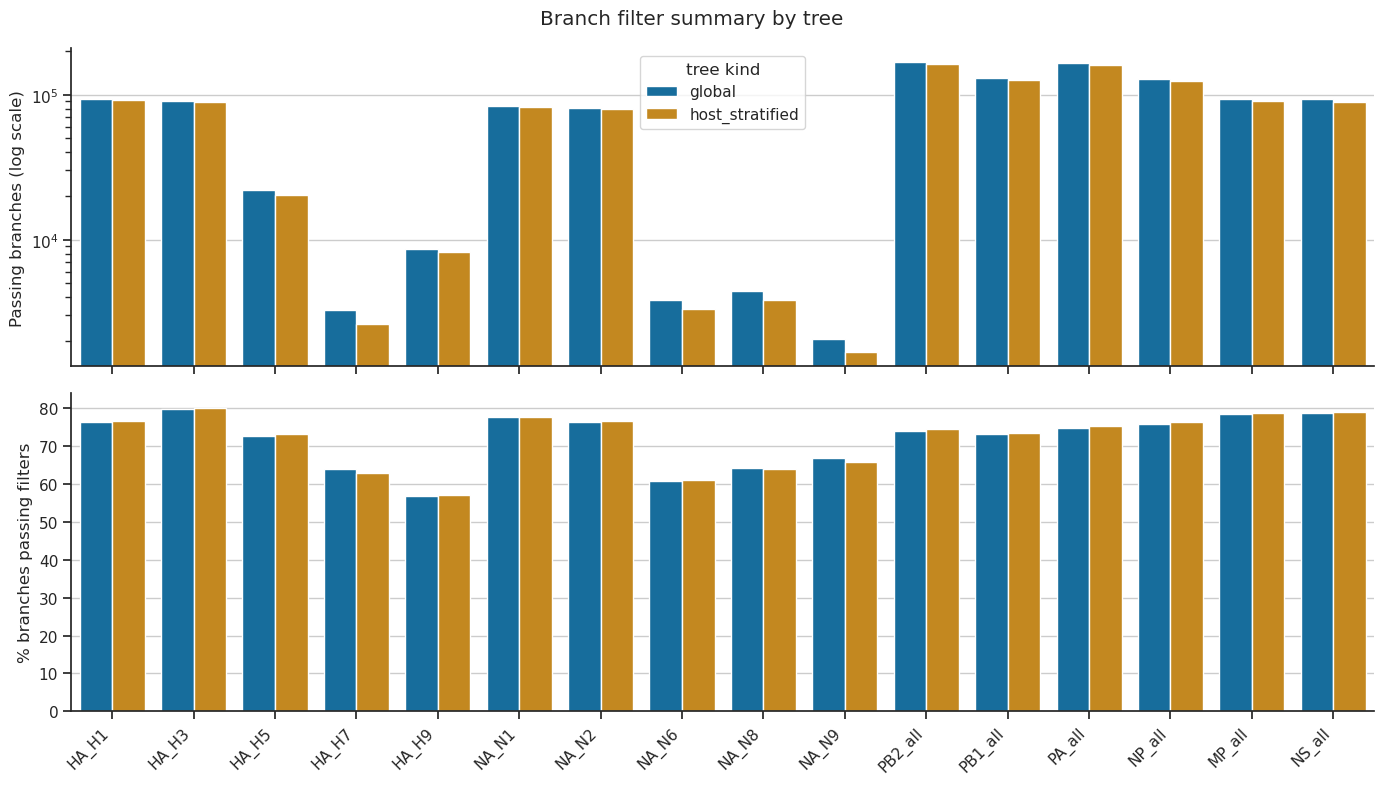

In [5]:

# Figure 1: branch filter summary (top: passing count log scale; bottom: % passing)
seg_order = ["HA", "NA", "PB2", "PB1", "PA", "NP", "MP", "NS"]
tree_kind_order = ["global", "host_stratified"]

plot_df = filter_df.copy()
plot_df["tree_label"] = plot_df["segment"] + "_" + plot_df["subtype"]
plot_df["seg_rank"] = plot_df["segment"].map({s: i for i, s in enumerate(seg_order)})
plot_df = plot_df.sort_values(["seg_rank", "subtype"])
tree_label_order = list(dict.fromkeys(plot_df["tree_label"].tolist()))

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=[14, 8], sharex=True)

sns.barplot(
    data=plot_df,
    x="tree_label", y="passing_branches", hue="tree_kind",
    order=tree_label_order, hue_order=tree_kind_order,
    ax=ax_top
)
ax_top.set(yscale="log", ylabel="Passing branches (log scale)", xlabel="")
ax_top.legend(title="tree kind")
ax_top.grid(axis="y")

sns.barplot(
    data=plot_df,
    x="tree_label", y="pct_passing_branches", hue="tree_kind",
    order=tree_label_order, hue_order=tree_kind_order,
    ax=ax_bot
)
ax_bot.get_legend().remove()
ax_bot.set_xticklabels(ax_bot.get_xticklabels(), rotation=45, ha="right")
ax_bot.set(ylabel="% branches passing filters", xlabel="")
ax_bot.grid(axis="y")

fig.suptitle("Branch filter summary by tree")
sns.despine()
plt.tight_layout()
plt.show()


/tmp/ipykernel_3813108/111334836.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bot.set_xticklabels(ax_bot.get_xticklabels(), rotation=45, ha="right")


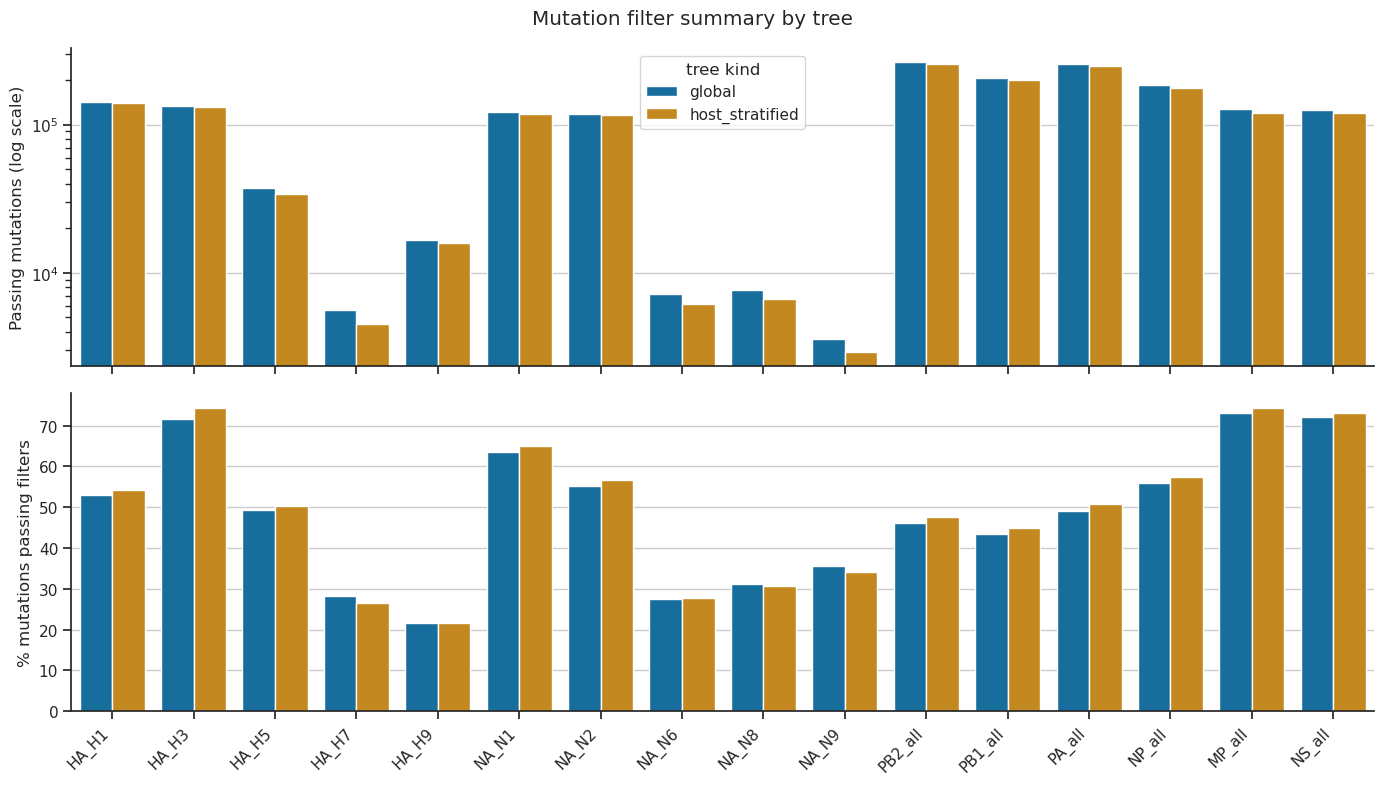

In [6]:

# Figure 2: mutation filter summary (top: passing count log scale; bottom: % passing)
plot_df2 = filter_df.copy()
plot_df2["tree_label"] = plot_df2["segment"] + "_" + plot_df2["subtype"]
plot_df2["seg_rank"] = plot_df2["segment"].map({s: i for i, s in enumerate(seg_order)})
plot_df2 = plot_df2.sort_values(["seg_rank", "subtype"])

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=[14, 8], sharex=True)

sns.barplot(
    data=plot_df2,
    x="tree_label", y="passing_mutations", hue="tree_kind",
    order=tree_label_order, hue_order=tree_kind_order,
    ax=ax_top
)
ax_top.set(yscale="log", ylabel="Passing mutations (log scale)", xlabel="")
ax_top.legend(title="tree kind")
ax_top.grid(axis="y")

sns.barplot(
    data=plot_df2,
    x="tree_label", y="pct_passing_mutations", hue="tree_kind",
    order=tree_label_order, hue_order=tree_kind_order,
    ax=ax_bot
)
ax_bot.get_legend().remove()
ax_bot.set_xticklabels(ax_bot.get_xticklabels(), rotation=45, ha="right")
ax_bot.set(ylabel="% mutations passing filters", xlabel="")
ax_bot.grid(axis="y")

fig.suptitle("Mutation filter summary by tree")
sns.despine()
plt.tight_layout()
plt.show()


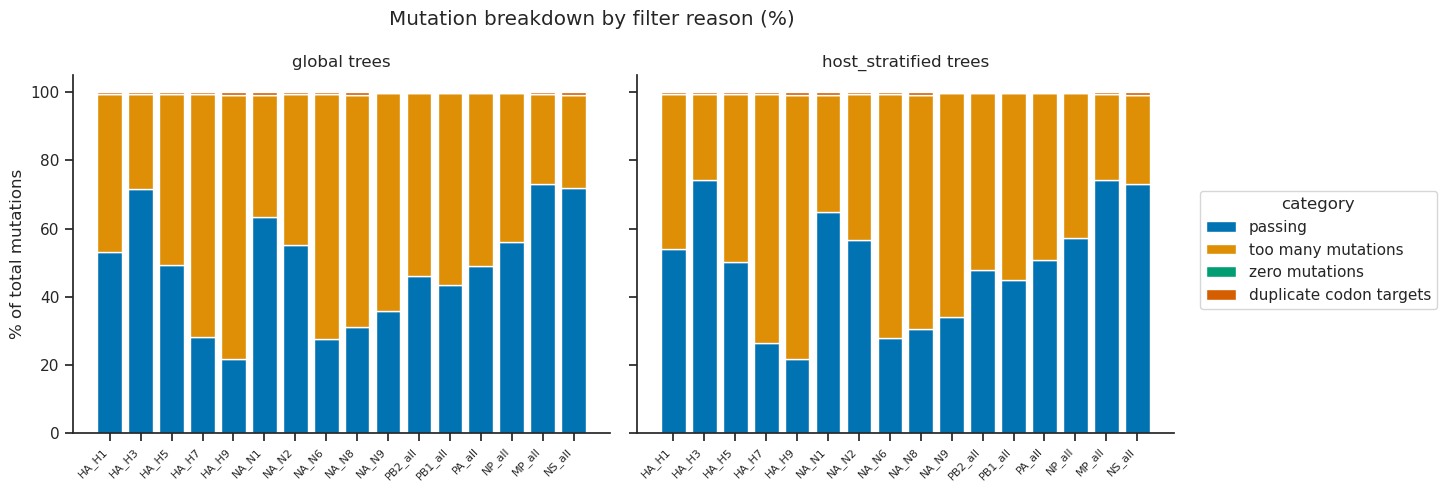

In [7]:

# Figure 3: % mutations by filter reason — stacked bar, faceted by tree kind
plot_df3 = filter_df.copy()
plot_df3["tree_label"] = plot_df3["segment"] + "_" + plot_df3["subtype"]
plot_df3["seg_rank"] = plot_df3["segment"].map({s: i for i, s in enumerate(seg_order)})
plot_df3["pct_passing"] = plot_df3["passing_mutations"] / plot_df3["total_mutations"] * 100
plot_df3["pct_too_many"] = plot_df3["filtered_by_too_many"] / plot_df3["total_mutations"] * 100
plot_df3["pct_zero"] = plot_df3["filtered_by_zero"] / plot_df3["total_mutations"] * 100
plot_df3["pct_duplicates"] = plot_df3["filtered_by_duplicates"] / plot_df3["total_mutations"] * 100
plot_df3 = plot_df3.sort_values(["seg_rank", "subtype"])
tree_label_order3 = list(dict.fromkeys(plot_df3["tree_label"].tolist()))

palette = sns.color_palette("colorblind", 4)
categories = [
    ("pct_passing",    "passing",                palette[0]),
    ("pct_too_many",   "too many mutations",      palette[1]),
    ("pct_zero",       "zero mutations",          palette[2]),
    ("pct_duplicates", "duplicate codon targets", palette[3]),
]

x = np.arange(len(tree_label_order3))
fig, axs = plt.subplots(1, len(tree_kind_order), figsize=[12, 5], sharey=True, squeeze=False)
axs = axs[0]
for i, (ax, tree_kind) in enumerate(zip(axs, tree_kind_order)):
    host_data = (
        plot_df3[plot_df3["tree_kind"] == tree_kind]
        .set_index("tree_label")
        .reindex(tree_label_order3)
    )
    bottoms = np.zeros(len(tree_label_order3))
    for col, name, color in categories:
        vals = host_data[col].fillna(0).values
        ax.bar(x, vals, bottom=bottoms, label=(name if i == 0 else None), color=color)
        bottoms += vals
    ax.set_xticks(x)
    ax.set_xticklabels(tree_label_order3, rotation=45, ha="right", fontsize=8)
    ax.set_title(f"{tree_kind} trees")
    ax.set_xlabel("")

axs[0].set_ylabel("% of total mutations")
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, title="category", bbox_to_anchor=(1.0, 0.5), loc="center left")
fig.suptitle("Mutation breakdown by filter reason (%)")
sns.despine()
plt.tight_layout()
plt.show()
